In [106]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [107]:
df = pd.read_csv('german_credit_cleaned.csv')

In [108]:
df.head()

,checking_acc_status,duration,cred_hist,purpose,loan_amt,saving_acc_bonds,present_employment_since,installment_rate,personal_stat_gender,other_debtors_guarantors,...,property,age,other_installment_plans,housing,num_curr_loans,job,num_people_provide_maint,telephone,is_foreign_worker,target
0,below_0,6,risky_acc_or_curr_loan_other,radio_tv,1169,unknown_no_saving_acc,above_7y,4,male:single,none,...,real_estate,67,none,own,2,skilled_official,1,yes,yes,good
1,below_200,48,curr_loans_paid_duly,radio_tv,5951,below_100,below_4y,2,female:divorced_or_married,none,...,real_estate,22,none,own,1,skilled_official,1,no,yes,bad
2,no_cheking_acc,12,risky_acc_or_curr_loan_other,education,2096,below_100,below_7y,2,male:single,none,...,real_estate,49,none,own,1,unskilled_resident,2,no,yes,good
3,below_0,42,curr_loans_paid_duly,furniture_equipment,7882,below_100,below_7y,2,male:single,guarantor,...,life_insurance_or_aggreements,45,none,for_free,1,skilled_official,2,no,yes,good
4,below_0,24,delay_in_past,car_new,4870,below_100,below_4y,3,male:single,none,...,unknown_or_no_property,53,none,for_free,2,skilled_official,2,no,yes,bad


In [109]:
df.columns

Index(['checking_acc_status', 'duration', 'cred_hist', 'purpose', 'loan_amt',
       'saving_acc_bonds', 'present_employment_since', 'installment_rate',
       'personal_stat_gender', 'other_debtors_guarantors',
       'present_residence_since', 'property', 'age', 'other_installment_plans',
       'housing', 'num_curr_loans', 'job', 'num_people_provide_maint',
       'telephone', 'is_foreign_worker', 'target'],
      dtype='object')

**Dropping Irrelevent columns**

In [110]:
df = df.drop(['telephone', 'num_people_provide_maint', 'other_installment_plans', 'num_curr_loans', 'housing', 'other_debtors_guarantors'], axis=1)

In [111]:
df.sample(5)

,checking_acc_status,duration,cred_hist,purpose,loan_amt,saving_acc_bonds,present_employment_since,installment_rate,personal_stat_gender,present_residence_since,property,age,job,is_foreign_worker,target
844,no_cheking_acc,18,curr_loans_paid_duly,furniture_equipment,3422,below_100,above_7y,4,male:single,4,life_insurance_or_aggreements,47,skilled_official,yes,good
237,below_200,21,curr_loans_paid_duly,business,2767,below_500,above_7y,4,male:divorced,2,car_or_other,61,unskilled_resident,yes,bad
106,no_cheking_acc,18,paid_duly_this_bank,car_new,6458,below_100,above_7y,2,male:single,4,unknown_or_no_property,39,management_or_self_emp,yes,bad
445,no_cheking_acc,9,risky_acc_or_curr_loan_other,education,1244,unknown_no_saving_acc,above_7y,4,female:divorced_or_married,4,life_insurance_or_aggreements,41,unskilled_resident,yes,good
121,no_cheking_acc,24,risky_acc_or_curr_loan_other,car_used,3868,below_100,above_7y,4,female:divorced_or_married,2,car_or_other,41,management_or_self_emp,yes,good


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   checking_acc_status       1000 non-null   object
 1   duration                  1000 non-null   int64 
 2   cred_hist                 1000 non-null   object
 3   purpose                   1000 non-null   object
 4   loan_amt                  1000 non-null   int64 
 5   saving_acc_bonds          1000 non-null   object
 6   present_employment_since  1000 non-null   object
 7   installment_rate          1000 non-null   int64 
 8   personal_stat_gender      1000 non-null   object
 9   present_residence_since   1000 non-null   int64 
 10  property                  1000 non-null   object
 11  age                       1000 non-null   int64 
 12  job                       1000 non-null   object
 13  is_foreign_worker         1000 non-null   object
 14  target                   

In [113]:
df.describe()

,duration,loan_amt,installment_rate,present_residence_since,age
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000
std,12.058814,2822.736876,1.118715,1.103718,11.375469
min,4.000000,250.000000,1.000000,1.000000,19.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000


In [114]:
df.shape

(1000, 15)

**EDA**

In [115]:
numeric_col = ['age', 'duration', 'loan_amt', 'installment_rate', 'present_residence_since']

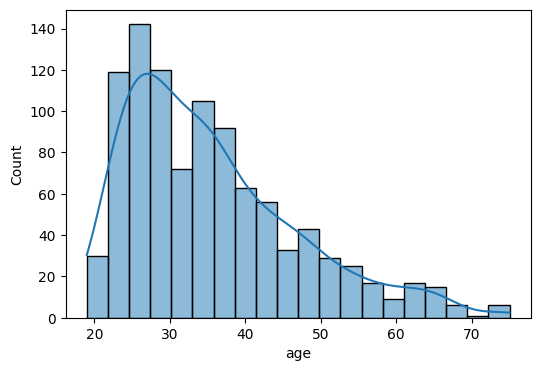

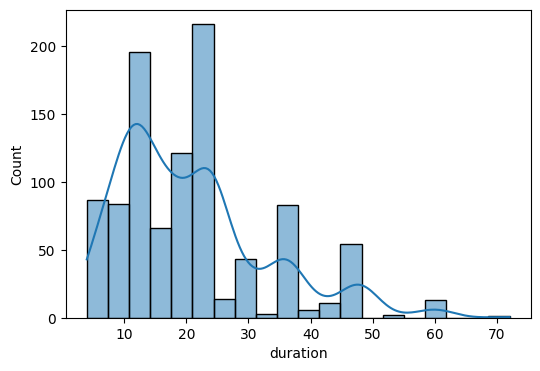

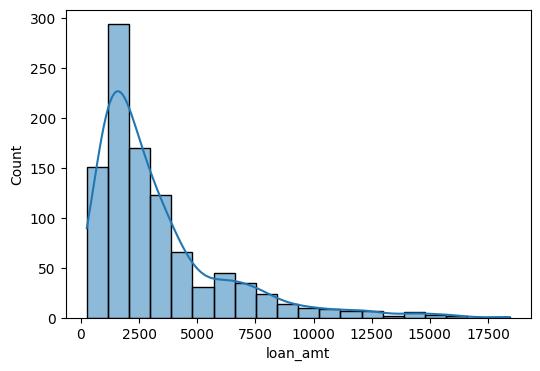

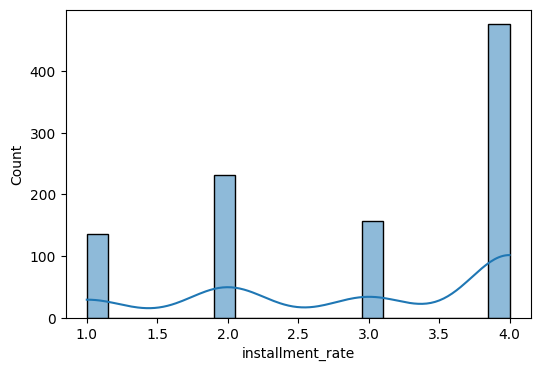

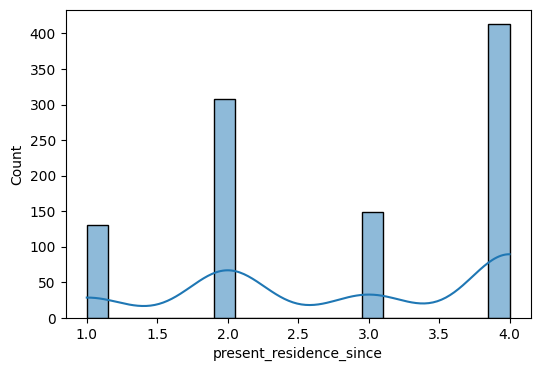

In [116]:
for col in numeric_col:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col], bins=20, kde=True)

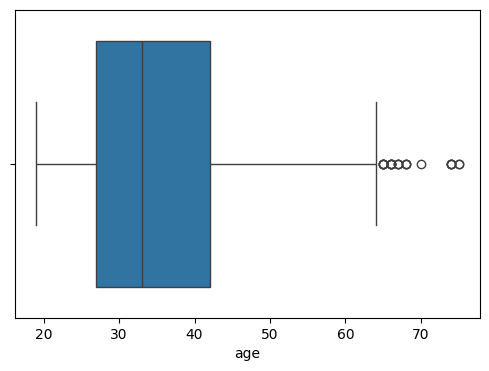

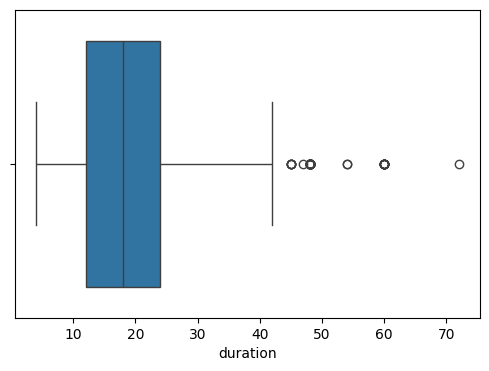

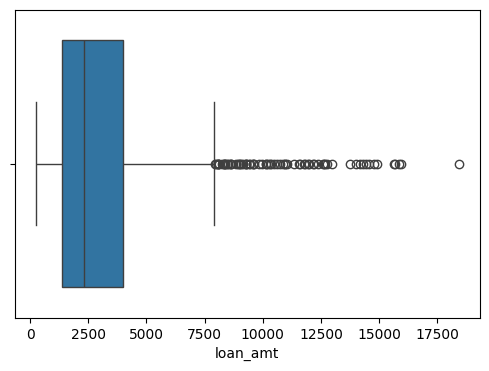

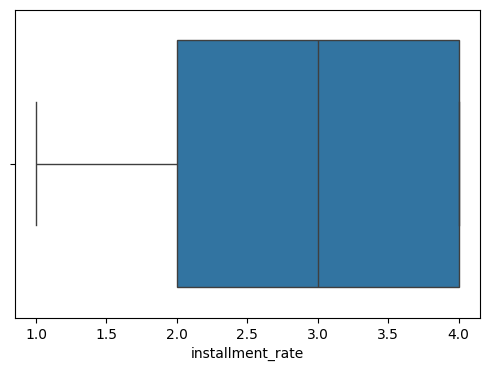

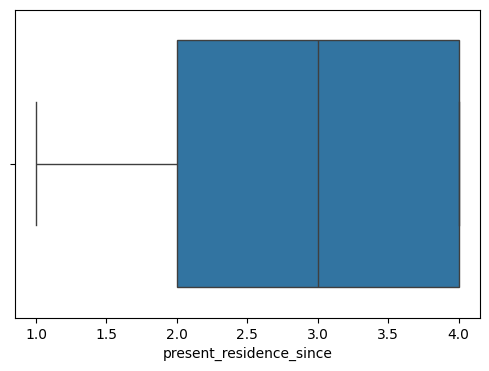

In [117]:
for col in numeric_col:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=df[col])

**Removing Outliers**

In [119]:
cols = ['loan_amt', 'duration', 'age']

for col in cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(df.shape)


(862, 15)


<Axes: xlabel='is_foreign_worker', ylabel='count'>

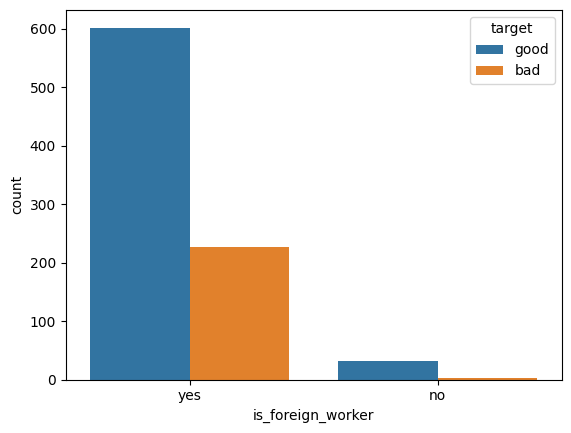

In [120]:
sns.countplot(data=df, x = 'is_foreign_worker', hue='target')

In [121]:
df.head()

,checking_acc_status,duration,cred_hist,purpose,loan_amt,saving_acc_bonds,present_employment_since,installment_rate,personal_stat_gender,present_residence_since,property,age,job,is_foreign_worker,target
2,no_cheking_acc,12,risky_acc_or_curr_loan_other,education,2096,below_100,below_7y,2,male:single,3,real_estate,49,unskilled_resident,yes,good
3,below_0,42,curr_loans_paid_duly,furniture_equipment,7882,below_100,below_7y,2,male:single,4,life_insurance_or_aggreements,45,skilled_official,yes,good
4,below_0,24,delay_in_past,car_new,4870,below_100,below_4y,3,male:single,4,unknown_or_no_property,53,skilled_official,yes,bad
6,no_cheking_acc,24,curr_loans_paid_duly,furniture_equipment,2835,below_1000,above_7y,3,male:single,4,life_insurance_or_aggreements,53,skilled_official,yes,good
7,below_200,36,curr_loans_paid_duly,car_used,6948,below_100,below_4y,2,male:single,2,car_or_other,35,management_or_self_emp,yes,good


([0, 1, 2, 3],
 [Text(0, 0, 'male:single'),
  Text(1, 0, 'male:divorced'),
  Text(2, 0, 'male:married_or_widowed'),
  Text(3, 0, 'female:divorced_or_married')])

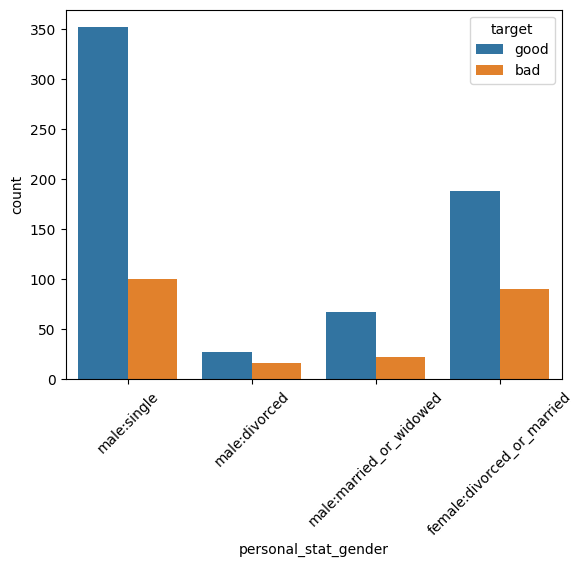

In [122]:
sns.countplot(data=df, x = 'personal_stat_gender', hue='target')
plt.xticks(rotation=45)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'education'),
  Text(1, 0, 'furniture_equipment'),
  Text(2, 0, 'car_new'),
  Text(3, 0, 'car_used'),
  Text(4, 0, 'radio_tv'),
  Text(5, 0, 'business'),
  Text(6, 0, 'domestic_applience'),
  Text(7, 0, 'repairs'),
  Text(8, 0, 'others'),
  Text(9, 0, 'retraining')])

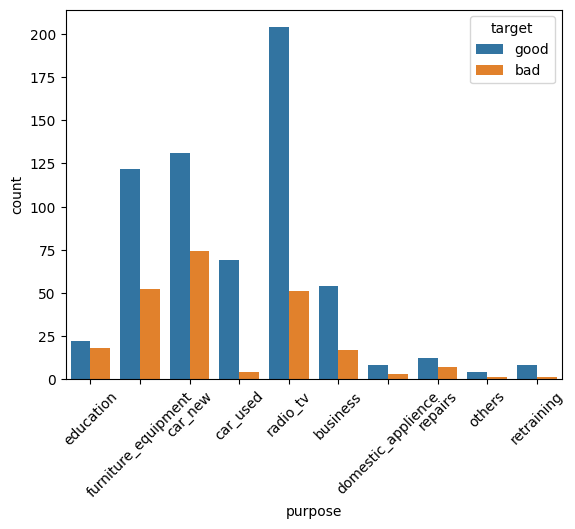

In [123]:
sns.countplot(data=df, x = 'purpose', hue='target')
plt.xticks(rotation=45)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'below_100'),
  Text(1, 0, 'below_1000'),
  Text(2, 0, 'above_1000'),
  Text(3, 0, 'below_500'),
  Text(4, 0, 'unknown_no_saving_acc')])

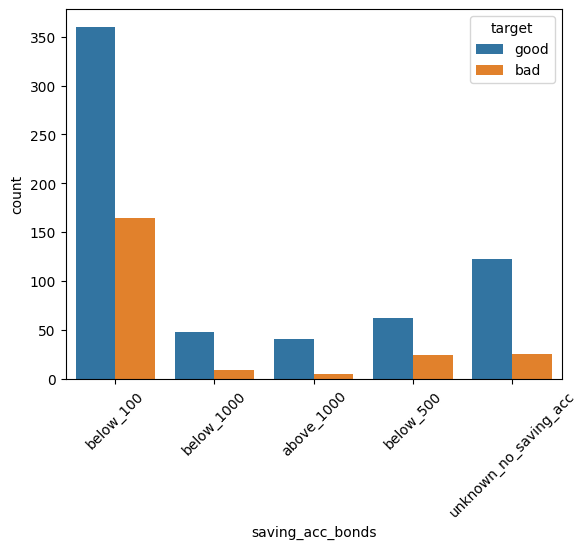

In [124]:
sns.countplot(data=df, x = 'saving_acc_bonds', hue='target')
plt.xticks(rotation=45)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'risky_acc_or_curr_loan_other'),
  Text(1, 0, 'curr_loans_paid_duly'),
  Text(2, 0, 'delay_in_past'),
  Text(3, 0, 'no_loan_or_paid_duly_other'),
  Text(4, 0, 'paid_duly_this_bank')])

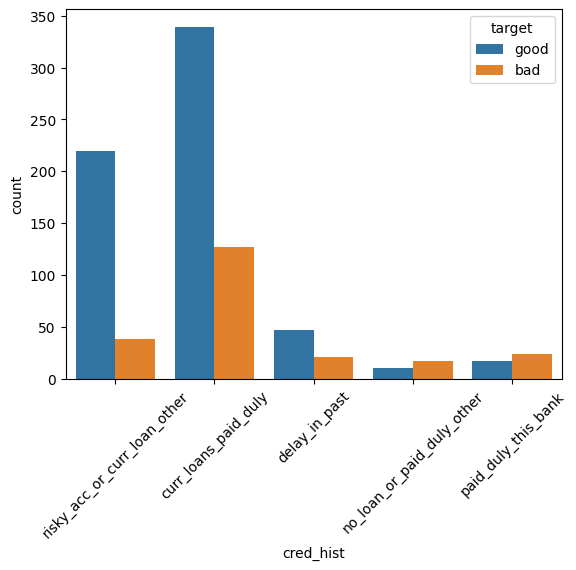

In [125]:
sns.countplot(data=df, x = 'cred_hist', hue='target')
plt.xticks(rotation=45)

In [126]:
df.head()

,checking_acc_status,duration,cred_hist,purpose,loan_amt,saving_acc_bonds,present_employment_since,installment_rate,personal_stat_gender,present_residence_since,property,age,job,is_foreign_worker,target
2,no_cheking_acc,12,risky_acc_or_curr_loan_other,education,2096,below_100,below_7y,2,male:single,3,real_estate,49,unskilled_resident,yes,good
3,below_0,42,curr_loans_paid_duly,furniture_equipment,7882,below_100,below_7y,2,male:single,4,life_insurance_or_aggreements,45,skilled_official,yes,good
4,below_0,24,delay_in_past,car_new,4870,below_100,below_4y,3,male:single,4,unknown_or_no_property,53,skilled_official,yes,bad
6,no_cheking_acc,24,curr_loans_paid_duly,furniture_equipment,2835,below_1000,above_7y,3,male:single,4,life_insurance_or_aggreements,53,skilled_official,yes,good
7,below_200,36,curr_loans_paid_duly,car_used,6948,below_100,below_4y,2,male:single,2,car_or_other,35,management_or_self_emp,yes,good


<Axes: xlabel='present_employment_since', ylabel='count'>

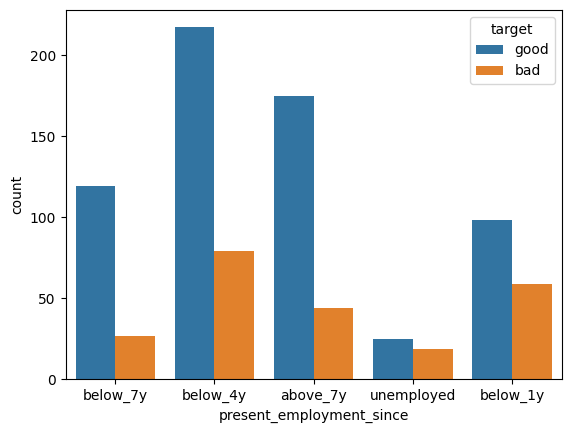

In [127]:
sns.countplot(data=df, x = 'present_employment_since', hue='target')

In [128]:
df['is_foreign_worker'].value_counts()

,count
is_foreign_worker,
yes,828
no,34


In [129]:
df['present_employment_since'].value_counts()

,count
present_employment_since,
below_4y,296
above_7y,219
below_1y,157
below_7y,146
unemployed,44


In [130]:
df['personal_stat_gender'].value_counts()

,count
personal_stat_gender,
male:single,452
female:divorced_or_married,278
male:married_or_widowed,89
male:divorced,43


<Axes: >

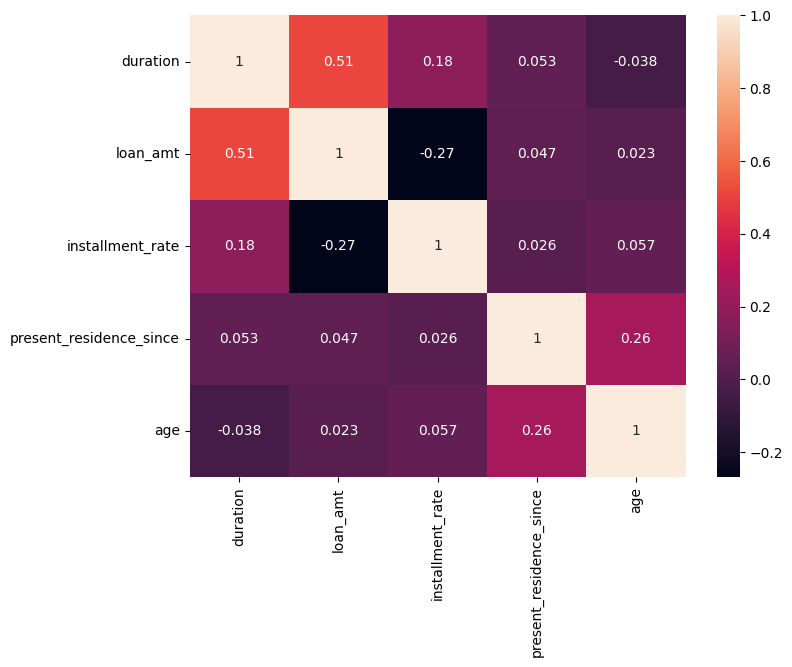

In [131]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only = True), annot=True)

**Data Scaling and Preprocessing**

In [163]:
from sklearn.preprocessing import StandardScaler
col = ['loan_amt', 'installment_rate', 'present_residence_since', 'age', 'duration']
scaler = StandardScaler()
df[col]=scaler.fit_transform(df[col])

In [133]:
df = pd.get_dummies(df, drop_first=True)
df = df.astype(int)

In [134]:
df.head()

,duration,loan_amt,installment_rate,present_residence_since,age,checking_acc_status_below_0,checking_acc_status_below_200,checking_acc_status_no_cheking_acc,cred_hist_delay_in_past,cred_hist_no_loan_or_paid_duly_other,...,personal_stat_gender_male:married_or_widowed,personal_stat_gender_male:single,property_life_insurance_or_aggreements,property_real_estate,property_unknown_or_no_property,job_skilled_official,job_unemployed_non_resident,job_unskilled_resident,is_foreign_worker_yes,target_good
2,0,0,0,0,1,0,0,1,0,0,...,0,1,0,1,0,0,0,1,1,1
3,2,3,0,1,1,1,0,0,0,0,...,0,1,1,0,0,1,0,0,1,1
4,0,1,0,1,1,1,0,0,1,0,...,0,1,0,0,1,1,0,0,1,0
6,0,0,0,1,1,0,0,1,0,0,...,0,1,1,0,0,1,0,0,1,1
7,2,2,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,1,1


In [135]:
df.columns

Index(['duration', 'loan_amt', 'installment_rate', 'present_residence_since',
       'age', 'checking_acc_status_below_0', 'checking_acc_status_below_200',
       'checking_acc_status_no_cheking_acc', 'cred_hist_delay_in_past',
       'cred_hist_no_loan_or_paid_duly_other', 'cred_hist_paid_duly_this_bank',
       'cred_hist_risky_acc_or_curr_loan_other', 'purpose_car_new',
       'purpose_car_used', 'purpose_domestic_applience', 'purpose_education',
       'purpose_furniture_equipment', 'purpose_others', 'purpose_radio_tv',
       'purpose_repairs', 'purpose_retraining', 'saving_acc_bonds_below_100',
       'saving_acc_bonds_below_1000', 'saving_acc_bonds_below_500',
       'saving_acc_bonds_unknown_no_saving_acc',
       'present_employment_since_below_1y',
       'present_employment_since_below_4y',
       'present_employment_since_below_7y',
       'present_employment_since_unemployed',
       'personal_stat_gender_male:divorced',
       'personal_stat_gender_male:married_or_widowed

In [136]:
features = {'checking_acc_status_below_0', 'checking_acc_status_below_200',
       'checking_acc_status_no_cheking_acc', 'cred_hist_delay_in_past',
       'cred_hist_no_loan_or_paid_duly_other', 'cred_hist_paid_duly_this_bank',
       'cred_hist_risky_acc_or_curr_loan_other', 'purpose_car_new',
       'purpose_car_used', 'purpose_domestic_applience', 'purpose_education',
       'purpose_furniture_equipment', 'purpose_others', 'purpose_radio_tv',
       'purpose_repairs', 'purpose_retraining', 'saving_acc_bonds_below_100',
       'saving_acc_bonds_below_1000', 'saving_acc_bonds_below_500',
       'saving_acc_bonds_unknown_no_saving_acc',
       'present_employment_since_below_1y',
       'present_employment_since_below_4y',
       'present_employment_since_below_7y',
       'present_employment_since_unemployed',
       'personal_stat_gender_male:divorced',
       'personal_stat_gender_male:married_or_widowed',
       'personal_stat_gender_male:single',
       'property_life_insurance_or_aggreements', 'property_real_estate',
       'property_unknown_or_no_property', 'job_skilled_official',
       'job_unemployed_non_resident', 'job_unskilled_resident',
       'is_foreign_worker_yes'}

In [137]:
from scipy.stats import chi2_contingency
for col in features:

    if col != 'target_good':

        table = pd.crosstab(df[col], df['target_good'])

        chi2, p, dof, expected = chi2_contingency(table)

        if p < 0.05:
            print(col, "-> Important ✅ (p =", round(p, 4), ")")
        else:
            print(col, "-> Not Important ❌ (p =", round(p, 4), ")")

purpose_radio_tv -> Important ✅ (p = 0.007 )
property_real_estate -> Important ✅ (p = 0.0102 )
cred_hist_no_loan_or_paid_duly_other -> Important ✅ (p = 0.0001 )
saving_acc_bonds_unknown_no_saving_acc -> Important ✅ (p = 0.0052 )
purpose_domestic_applience -> Not Important ❌ (p = 1.0 )
saving_acc_bonds_below_500 -> Not Important ❌ (p = 0.8462 )
present_employment_since_below_1y -> Important ✅ (p = 0.0007 )
cred_hist_delay_in_past -> Not Important ❌ (p = 0.4714 )
purpose_furniture_equipment -> Not Important ❌ (p = 0.292 )
purpose_others -> Not Important ❌ (p = 1.0 )
personal_stat_gender_male:single -> Important ✅ (p = 0.0032 )
cred_hist_risky_acc_or_curr_loan_other -> Important ✅ (p = 0.0 )
present_employment_since_below_4y -> Not Important ❌ (p = 0.9731 )
cred_hist_paid_duly_this_bank -> Important ✅ (p = 0.0 )
purpose_repairs -> Not Important ❌ (p = 0.438 )
present_employment_since_below_7y -> Important ✅ (p = 0.0221 )
job_skilled_official -> Not Important ❌ (p = 0.7353 )
purpose_educat

In [139]:
final_df =df[['age', 'duration', 'loan_amt', 'installment_rate', 'present_residence_since','property_real_estate','purpose_car_used', 'present_employment_since_below_1y', 'saving_acc_bonds_unknown_no_saving_acc', 'purpose_radio_tv', 'present_employment_since_below_7y',
            'purpose_education', 'checking_acc_status_no_cheking_acc', 'cred_hist_risky_acc_or_curr_loan_other', 'checking_acc_status_below_200',
           'personal_stat_gender_male:single', 'checking_acc_status_below_0', 'cred_hist_no_loan_or_paid_duly_other', 'purpose_car_new','purpose_car_new',
           'saving_acc_bonds_below_1000',  'is_foreign_worker_yes', 'cred_hist_paid_duly_this_bank', 'target_good']]



**Splitting Columns**

In [140]:
from sklearn.model_selection import train_test_split

In [141]:
X = final_df.drop('target_good', axis=1)
y = final_df['target_good']

In [142]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [143]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Applying Model**

In [144]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix


In [145]:
model = LogisticRegression(C=5, penalty='l1', solver='liblinear', max_iter = 1000)

In [146]:
model.fit(X_train, y_train)


LogisticRegression(C=5, max_iter=1000, penalty='l1', solver='liblinear')

In [147]:
y_prob = model.predict_proba(X_test)[:,1]

In [148]:
y_pred = (y_prob > 0.6).astype(int)

In [149]:
y_pred = model.predict(X_test)

In [150]:
accuracy_score(y_test, y_pred)

0.8

In [151]:
confusion_matrix(y_test, y_pred)

array([[ 38,  43],
       [ 14, 190]])

In [152]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.47      0.57        81
           1       0.82      0.93      0.87       204

    accuracy                           0.80       285
   macro avg       0.77      0.70      0.72       285
weighted avg       0.79      0.80      0.78       285



In [153]:
y.value_counts()

,count
target_good,
1,634
0,228
